In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**Columns description**
- gender: Customer's gender (Male/Female)
- SeniorCitizen: The customer is a senior citizen (1 = Yes, 0 = No)
- Partner: Whether the customer has a partner (Yes/No)
- Dependents: Whether the customer has dependents (Yes/No)
- tenure: Number of months the customer has stayed with the company
- PhoneService: Whether the customer has a phone service (Yes/No)
- MultipleLines: Whether the customer has multiple phone lines (No, Yes, No phone service)
- InternetService: Type of internet service (DSL, Fiber optic, No)
- OnlineSecurity: Whether the customer has online security (Yes, No, No internet service)
- OnlineBackup: Whether the customer has online backup (Yes, No, No internet service)
- DeviceProtection: Whether the customer has device protection (Yes, No, No internet service)
- TechSupport: Whether the customer has tech support (Yes, No, No internet service)
- StreamingTV: Whether the customer has streaming TV (Yes, No, No internet service)
- StreamingMovies: Whether the customer has streaming movies (Yes, No, No internet service)
- Contract: Type of contract (Month-to-month, One year, Two year)
- PaperlessBilling: Whether the customer has paperless billing (Yes/No)
- PaymentMethod: Payment method used (Electronic check, Mailed check, Bank transfer, Credit card)
- MonthlyCharges: Monthly charges the customer pays
- TotalCharges: Total amount charged to the customer
- Churn: Whether the customer has churned (Yes/No)

In [3]:
df_churn = pd.read_csv('data/customer_churn_telecom_services.csv')

In [4]:
df_churn.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

Churn Rate (Yes): 26.54%
Churn Rate (No): 73.46%


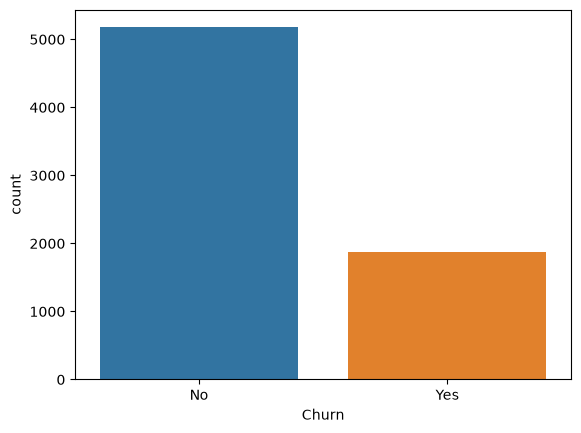

In [ ]:
# Churn = Yes significa que o cliente cancelou o serviço e deixou de ser cliente da empresa.
sns.countplot(
    data=df_churn,
    x='Churn',
    hue='Churn',
)

print(f"Churn Rate (Yes): {(df_churn['Churn'] == 'Yes').sum() / len(df_churn) * 100:.2f}%")
print(f"Churn Rate (No): {(df_churn['Churn'] == 'No').sum() / len(df_churn) * 100:.2f}%")

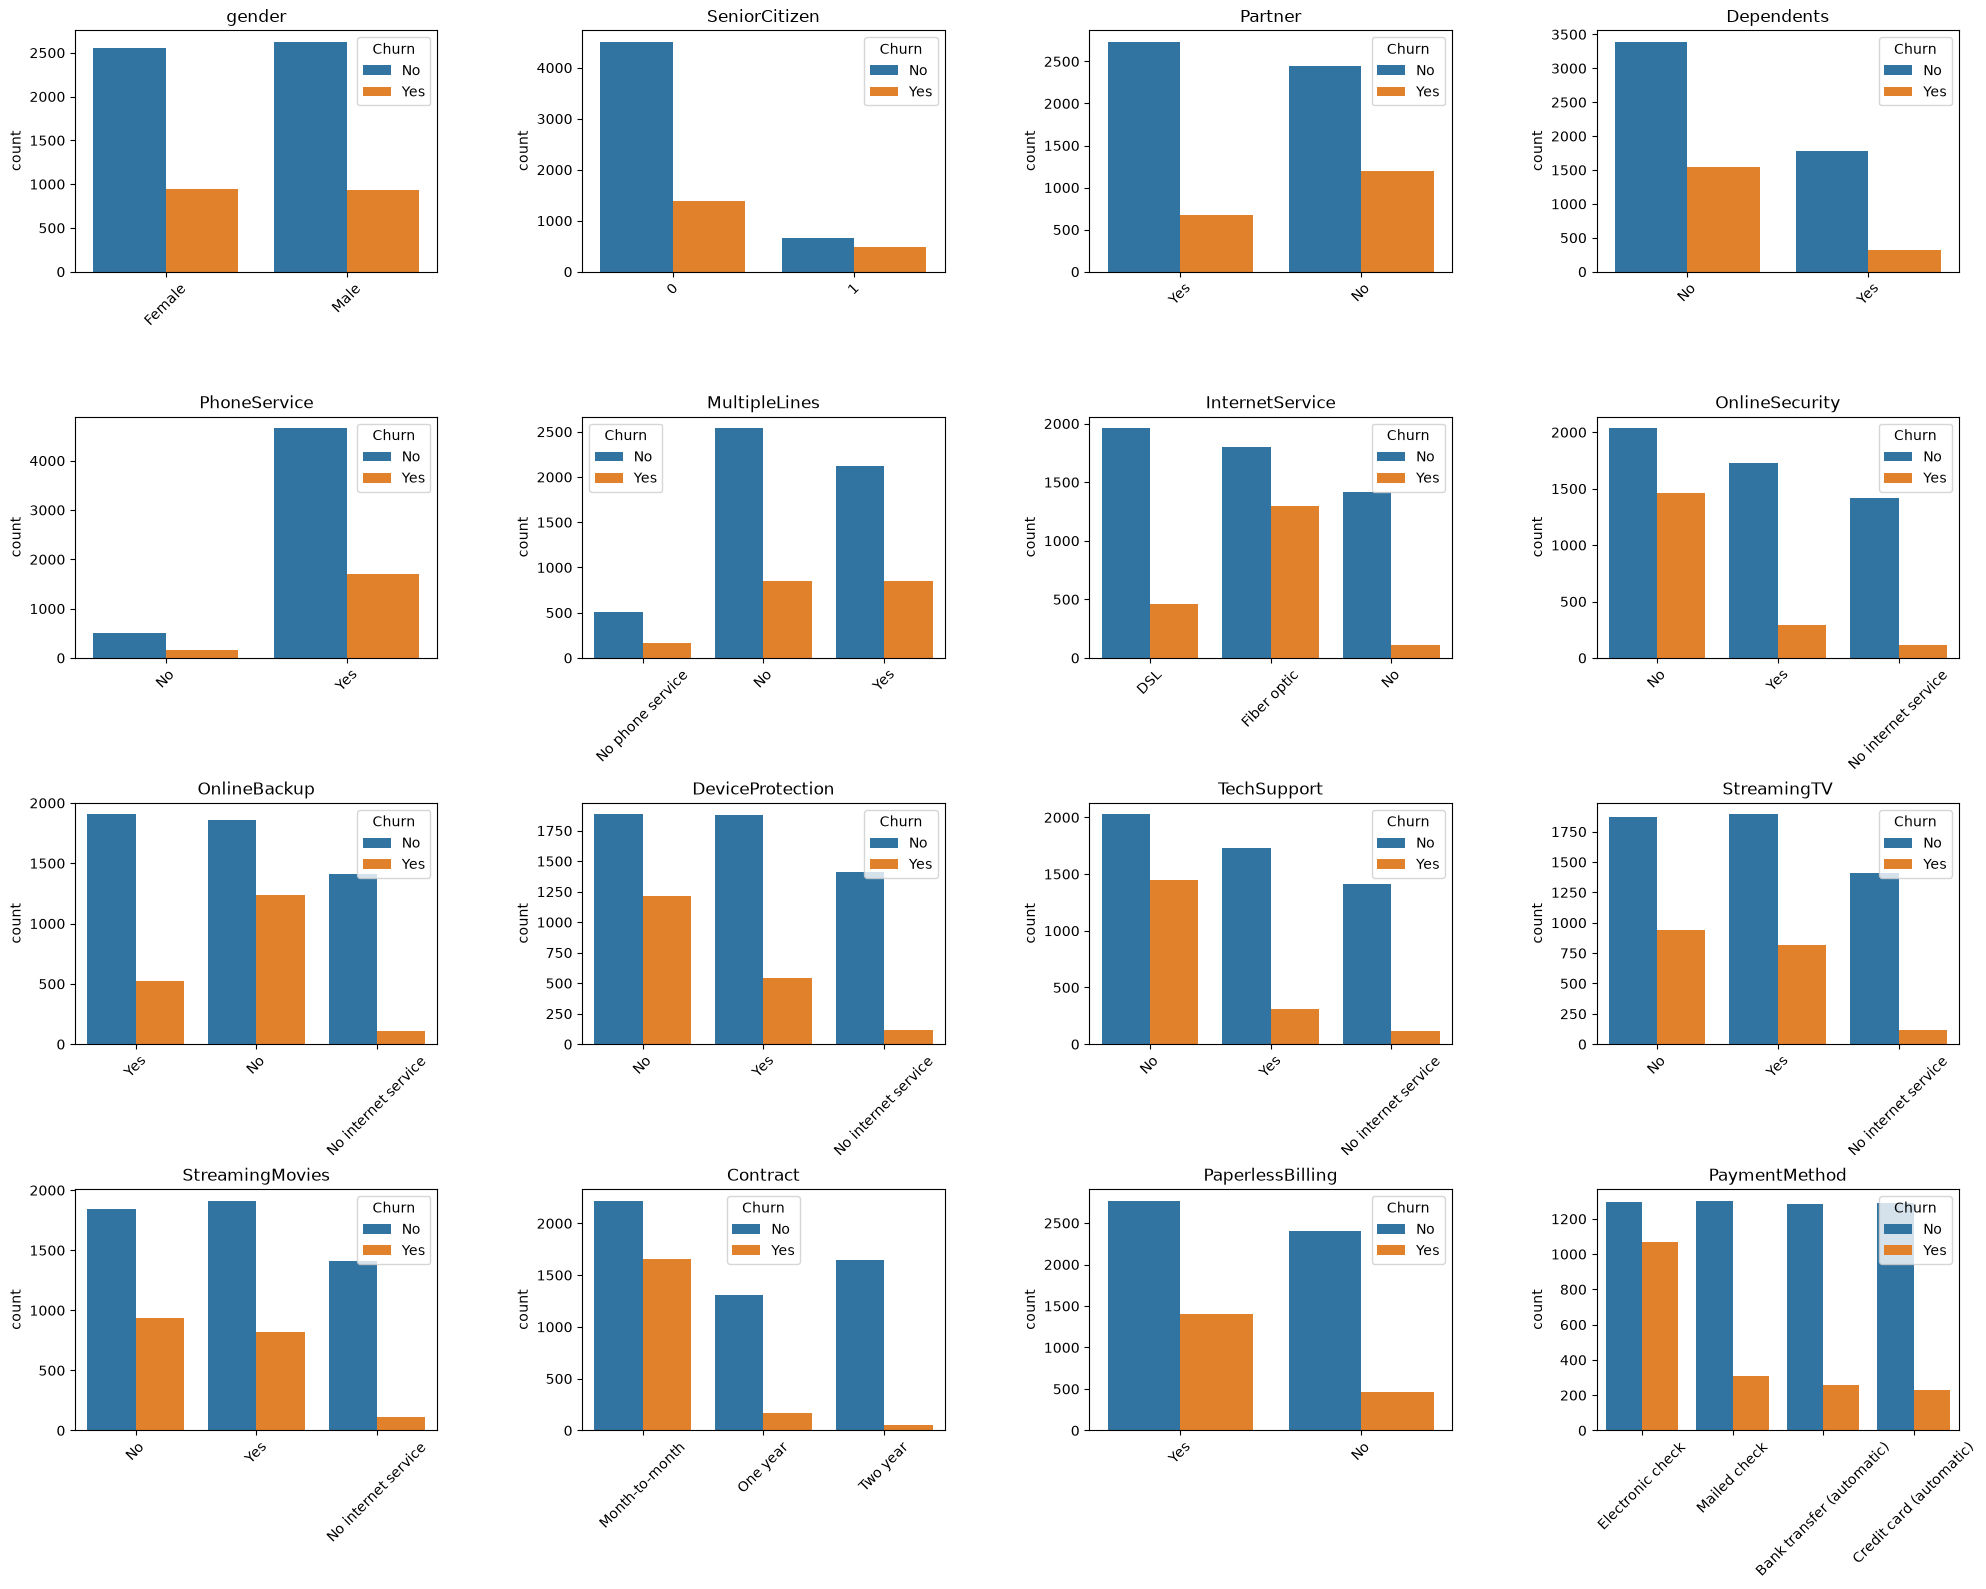

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

df_churn['Churn_num'] = (df_churn['Churn'] == 'Yes').astype(int)

n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 4*n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    sns.countplot(
        data=df_churn,
        x=col,
        hue='Churn',
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.subplots_adjust(hspace=0.6, wspace=0.4)
plt.show()

Na maioria das classes a proporção entre clientes que cancelaram ou não o serviço parece estar equilibrada, com o número de clientes que não cancelaram se mantendo significativamente maior em cada uma das categorias. Exceções notáveis:

- Forma de contrato
    - A forma de contrato tem uma relação notável no Churn rate, Isso sugere que vínculos contratuais mais longos estão associados a uma maior retenção de clientes, seja pela menor flexibilidade para cancelamento ou por um maior comprometimento com o serviço.

- Clientes sem serviço de internet
    - Clientes sem serviço de internet apresentam taxas de churn significativamente menores que os demais grupos. Uma possível explicação é que esses clientes possuem um relacionamento mais simples com a empresa, estando menos expostos a problemas de qualidade de conexão e a comparações frequentes com concorrentes. Além disso, é importante investigar possíveis efeitos de variáveis como o tipo de contrato, que podem estar contribuindo para essa diferença.

- Forma de pagamento
    - Por fim, entre os métodos de pagamento o cheque eletrônico apresenta um churn rate significativamente maior que os outros, o que pode se dar por conta de uma experiência de pagamento menos conveniente em comparação aos outros métodos.

In [27]:
from IPython.display import display

for col in ['InternetService', 'TechSupport', 'OnlineSecurity']:

    print(f'\n=== {col} x Contract ===')

    display(
        pd.crosstab(
            df_churn[col],
            df_churn['Contract'],
            normalize='index'
        )
    )


=== InternetService x Contract ===


Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,0.505163,0.235440,0.259397
Fiber optic,0.687339,0.174096,0.138566
No,0.343381,0.238532,0.418087



=== TechSupport x Contract ===


Contract,Month-to-month,One year,Two year
TechSupport,,,
No,0.771667,0.160380,0.067953
No internet service,0.343381,0.238532,0.418087
Yes,0.328278,0.270059,0.401663



=== OnlineSecurity x Contract ===


Contract,Month-to-month,One year,Two year
OnlineSecurity,,,
No,0.752144,0.159234,0.088622
No internet service,0.343381,0.238532,0.418087
Yes,0.356612,0.273403,0.369985


In [34]:
sem_internet = df_churn[df_churn['InternetService'] == 'No']
#sem_internet.describe(include='all')

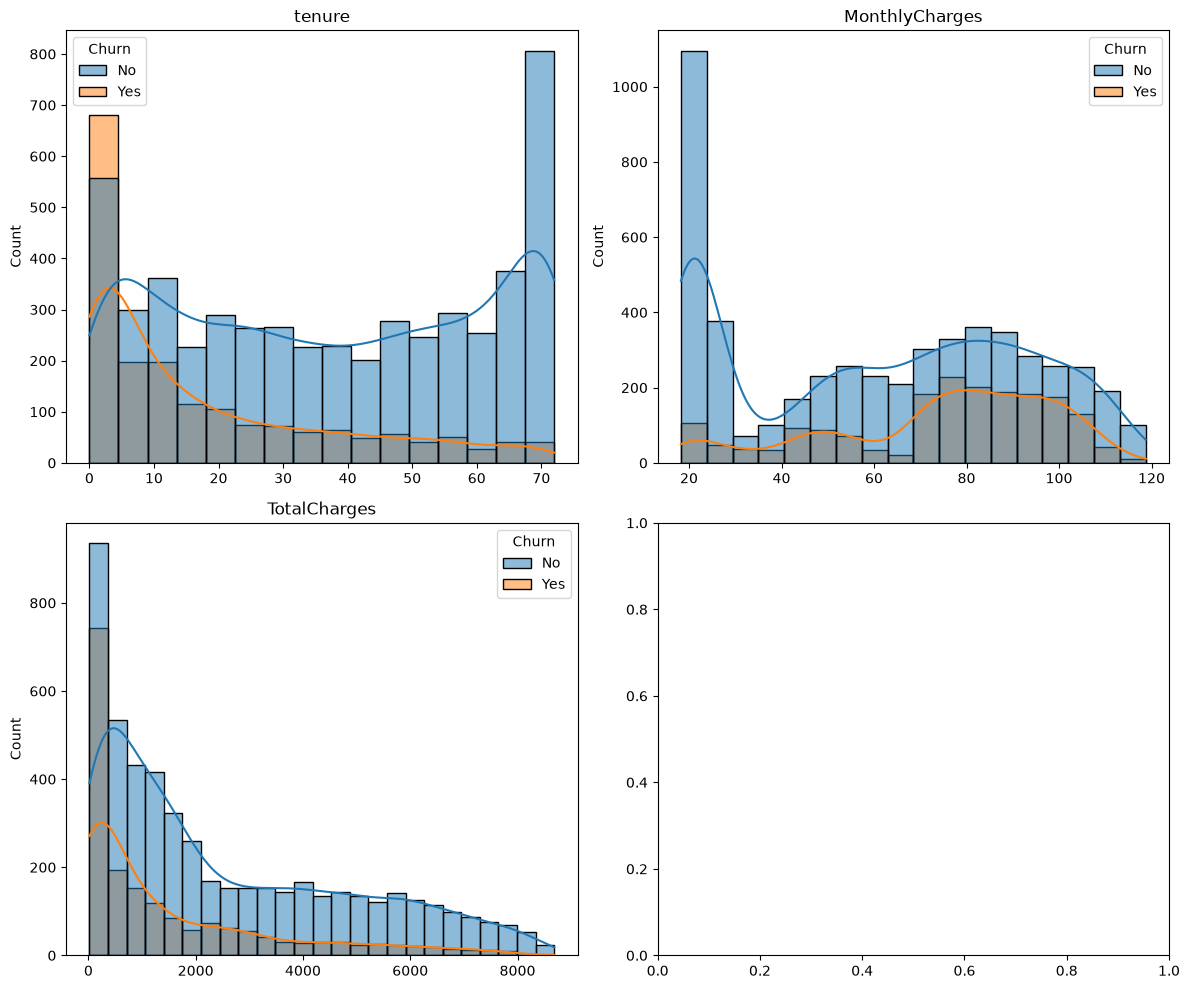

In [29]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 5*n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.histplot(
        data=df_churn,
        x=col,
        hue='Churn',
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_xlabel('')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

A relação entre as variáveis númericas e o churn aparenta ser bastante intuitiva:

- Clientes com relacionamentos mais longos (ternure) tendem a cancelar menos
- Clientes com mensalidades menores tendem a cancelar menos
- A distribuição entre as duas classes é parecida quando observamos o total pago. Entretanto, clientes que permanecem na empresa tendem a acumular valores totais mais elevados. Esse resultado é esperado, uma vez que TotalCharges está fortemente associado ao tempo de permanência (tenure), e clientes de longo prazo naturalmente acumulam um volume maior de pagamentos ao longo do relacionamento.

- qual o perfil dos clientes que não possuem internet? E os que possuem?
- relações das variáveis com o target (heatmap)
- Qual o grupo de maior churn (quais serviços/faixa etária)? (Quais serviços mais retem, quantidade de serviço influencia?)
- Quais serviços tem os clientes mais fiéis/ e menos? -> verificar método de pagamento e faixa etária nesses casos também
- Quais serviços são mais rentáveis
- 